<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/Linus_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================================
# UPLOAD EXCEL DATASET
# =========================================================

from google.colab import files

uploaded = files.upload()

# =========================================================
# LOAD DATASET
# =========================================================

import pandas as pd
df = pd.read_excel("Linus SME Dataset.xlsx")

# View dataset
df.head()

Saving Linus SME Dataset.xlsx to Linus SME Dataset (1).xlsx


,Respondent_ID,Sector,Years_Operation,Employees,Ownership,Position,FR1,FR2,FR3,FR4,...,Year,Registered_SMEs,Access_to_Credit_Index,Managerial_Capacity_Index,Operational_Efficiency_Index,SME_Performance_Index,SME_Resilience_Index,GDP_Growth_Percent,Inflation_Percent,SME_Failure_Rate_Percent
0,1,Construction,6-10 years,Less than 10,Partnership,Financial Officer,1,1,1,1,...,1995.0,50000.0,41.72,43.19,43.05,51.48,46.54,5.71,9.25,21.83
1,2,Manufacturing,Less than 2 years,50-99,Limited Company,Owner,4,3,3,4,...,1996.0,56174.0,43.75,49.94,41.52,46.38,42.64,5.55,12.25,19.53
2,3,Construction,Above 10 years,Less than 10,Sole Proprietorship,Owner,3,2,3,3,...,1997.0,62850.0,45.12,51.25,46.56,55.91,51.40,3.11,14.84,19.19
3,4,Hospitality,Less than 2 years,10-49,Partnership,Financial Officer,1,1,1,1,...,1998.0,73777.0,43.78,44.18,43.13,55.76,44.64,7.97,5.92,18.95
4,5,Services,6-10 years,50-99,Partnership,Owner,2,1,3,1,...,1999.0,84033.0,48.86,46.26,41.57,48.17,49.56,4.25,4.69,23.87


INSTALL REQUIRED PACKAGES

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn openpyxl statsmodels semopy xgboost graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.2 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=8ad7038d1fe9dc72dd66ed5f32d8896c5b725ae30ec2be999758cc6d6cf408a5
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


Frequency and Percentage


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("Linus SME Dataset.xlsx")

# Function to compute frequency and percentage
def freq_percent(data, column):
    freq = data[column].value_counts().reset_index()
    freq.columns = [column, "Frequency"]
    freq["Percentage"] = (freq["Frequency"] / len(data)) * 100
    return freq

# Demographic variables
variables = ["Sector", "Years_Operation", "Employees", "Ownership", "Position"]

# Run analysis for each variable
for var in variables:
    print("\n")
    print("=" * 50)
    print(f"Frequency and Percentage for {var}")
    print("=" * 50)
    result = freq_percent(df, var)
    print(result)

all_tables = {}

for var in variables:
    all_tables[var] = freq_percent(df, var)



Frequency and Percentage for Sector
          Sector  Frequency  Percentage
0    Hospitality         97   24.310777
1       Services         82   20.551378
2          Trade         80   20.050125
3  Manufacturing         75   18.796992
4   Construction         65   16.290727


Frequency and Percentage for Years_Operation
     Years_Operation  Frequency  Percentage
0  Less than 2 years        114   28.571429
1         6-10 years        102   25.563910
2          2-5 years         95   23.809524
3     Above 10 years         88   22.055138


Frequency and Percentage for Employees
      Employees  Frequency  Percentage
0         10-49        145   36.340852
1         50-99        133   33.333333
2  Less than 10        121   30.325815


Frequency and Percentage for Ownership
             Ownership  Frequency  Percentage
0      Limited Company        138   34.586466
1          Partnership        137   34.335840
2  Sole Proprietorship        124   31.077694


Frequency and Percentage for Po

FULL ENHANCED PYTHON CODE for The complete Analysis


================ DESCRIPTIVE STATISTICS ================

       Respondent_ID        FR1        FR2        FR3        FR4        FR5  \
count      30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean       15.500000   2.566667   2.566667   2.533333   2.533333   2.566667   
std         8.803408   1.304722   1.165106   1.224276   1.332183   1.165106   
min         1.000000   1.000000   1.000000   1.000000   1.000000   1.000000   
25%         8.250000   1.000000   2.000000   1.000000   1.000000   2.000000   
50%        15.500000   3.000000   2.500000   3.000000   3.000000   2.500000   
75%        22.750000   4.000000   4.000000   4.000000   4.000000   4.000000   
max        30.000000   4.000000   4.000000   4.000000   4.000000   4.000000   

             MR1        MR2        MR3        MR4  ...         Year  \
count  30.000000  30.000000  30.000000  30.000000  ...    30.000000   
mean    2.400000   2.300000   2.466667   2.400000  ...  2009.500000   
std     1.037238

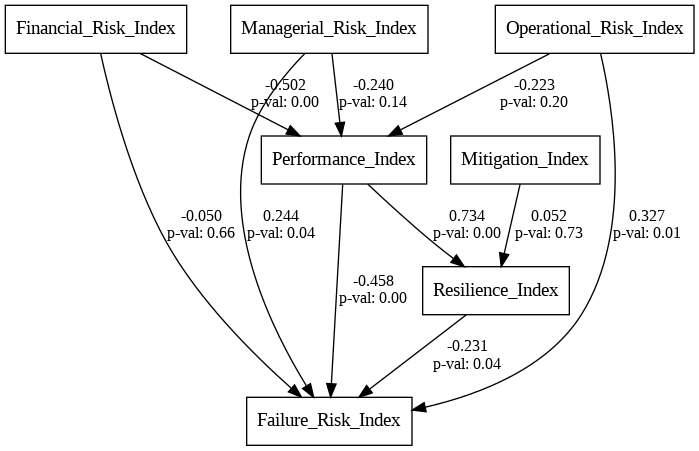

Optimization terminated successfully.
         Current function value: 0.170183
         Iterations 11

================ LOGISTIC REGRESSION SUMMARY ================

                           Logit Regression Results                           
Dep. Variable:     SME_Failure_Status   No. Observations:                   30
Model:                          Logit   Df Residuals:                       22
Method:                           MLE   Df Model:                            7
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.7537
Time:                        09:10:54   Log-Likelihood:                -5.1055
converged:                       True   LL-Null:                       -20.728
Covariance Type:            nonrobust   LLR p-value:                 5.604e-05
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const        

In [ ]:
import pandas as pd
import numpy as np

# ===============================
# LOAD DATA
# ===============================
df = pd.read_excel("Linus SME Dataset.xlsx")

# ===============================
# DATA PREPROCESSING
# ===============================
df = df.dropna()

binary_cols = ["SME_Failure_Status"]
df[binary_cols] = df[binary_cols].astype(int)

features = [
    "Financial_Risk_Index",
    "Managerial_Risk_Index",
    "Operational_Risk_Index",
    "Performance_Index",
    "Mitigation_Index",
    "Resilience_Index",
    "Integrated_Modeling_Index"
]

X = df[features]
y = df["SME_Failure_Status"]

print("\n================ DESCRIPTIVE STATISTICS ================\n")
print(df.describe())

print("\n================ DATA INFO ================\n")
print(df.info())

# ===============================
# RELIABILITY (CRONBACH ALPHA)
# ===============================
def cronbach_alpha(data):
    item_variances = data.var(axis=0, ddof=1)
    total_score = data.sum(axis=1)
    n_items = data.shape[1]
    total_variance = total_score.var(ddof=1)
    alpha = (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

risk_items = df[[c for c in df.columns if "FR" in c or "MR" in c or "OR" in c]]

print("\n================ RELIABILITY (CRONBACH ALPHA) ================\n")
print("Cronbach Alpha:", cronbach_alpha(risk_items))

# ===============================
# PCA
# ===============================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=["PC1","PC2","PC3"])

print("\n================ PCA LOADINGS ================\n")
print(pca.explained_variance_ratio_)

print("\n================ PCA SAMPLE OUTPUT ================\n")
print(pca_df.head())

# ===============================
# TRAIN TEST SPLIT
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ===============================
# MODELS
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

log_model = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(eval_metric="logloss")
svm = SVC(probability=True)

log_model.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
svm.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)
svm_pred = svm.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]
svm_prob = svm.predict_proba(X_test)[:,1]

# ===============================
# EVALUATION FUNCTION
# ===============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, mean_squared_error, r2_score

def evaluate(y_true, pred, prob):
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred)
    rec = recall_score(y_true, pred)
    auc = roc_auc_score(y_true, prob)

    mse = mean_squared_error(y_true, prob)
    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - prob) / (y_true + 1e-6))) * 100
    r2 = r2_score(y_true, prob)

    return [acc, prec, rec, auc, mse, rmse, mape, r2]

# ===============================
# MODEL RESULTS TABLE
# ===============================
models = {
    "Logistic Regression": (log_pred, log_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "SVM": (svm_pred, svm_prob)
}

results = {}

for name, (pred, prob) in models.items():
    results[name] = evaluate(y_test, pred, prob)

results_df = pd.DataFrame(results, index=[
    "Accuracy","Precision","Recall","AUC","MSE","RMSE","MAPE","R2"
])

print("\n================ MODEL PERFORMANCE RESULTS ================\n")
print(results_df)

# ===============================
# ENSEMBLE MODEL
# ===============================
ensemble_prob = (log_prob + rf_prob + xgb_prob + svm_prob) / 4
ensemble_pred = (ensemble_prob > 0.5).astype(int)

ensemble_results = evaluate(y_test, ensemble_pred, ensemble_prob)

print("\n================ ENSEMBLE MODEL RESULTS ================\n")
print(pd.DataFrame(ensemble_results, index=[
    "Accuracy","Precision","Recall","AUC","MSE","RMSE","MAPE","R2"
], columns=["Ensemble"]))

# ===============================
# SEM MODEL
# ===============================
from semopy import Model, semplot

sem_desc = """
Performance_Index ~ Financial_Risk_Index + Managerial_Risk_Index + Operational_Risk_Index
Resilience_Index ~ Mitigation_Index + Performance_Index
Failure_Risk_Index ~ Financial_Risk_Index + Managerial_Risk_Index + Operational_Risk_Index + Performance_Index + Resilience_Index
"""

model = Model(sem_desc)
res = model.fit(df)

print("\n================ SEM ESTIMATES ================\n")
print(model.inspect())

# SEM DIAGRAM
semplot(model, "sem_diagram.png")

from IPython.display import Image
print("\n================ SEM DIAGRAM ================\n")
display(Image("sem_diagram.png"))

# ===============================
# LOGISTIC REGRESSION (STATSMODELS)
# ===============================
import statsmodels.api as sm

X_sm = sm.add_constant(X)
logit_model = sm.Logit(y, X_sm).fit()

print("\n================ LOGISTIC REGRESSION SUMMARY ================\n")
print(logit_model.summary())

# ===============================
# MARGINAL EFFECTS
# ===============================
marginal_effects = logit_model.get_margeff()

print("\n================ MARGINAL EFFECTS ================\n")
print(marginal_effects.summary())

# ===============================
# FINAL MODEL RANKING
# ===============================
print("\n================ MODEL RANKING BY AUC ================\n")
print(results_df.T.sort_values(by="AUC", ascending=False))